In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

In [3]:
year = "2026"
month = "04"

In [4]:
command = f"wget -O ../datasets/raw/{year}-{month}.parquet https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

In [5]:
try:
    subprocess.run(command, shell=True, check=True)
    print("Download complete!")
except subprocess.CalledProcessError as e:
    print(f"Wget failed with exit code: {e.returncode}")

[0] Downloading 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-04.parquet' ...
Saving '../datasets/raw/2026-04.parquet'
HTTP response 200  [https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-04.parquet]
Download complete!


In [7]:
with open(f"../datasets/raw/{year}-{month}.parquet","rb") as f:
    df = pd.read_parquet(f, engine = "pyarrow")
print(df.shape)
print(df.info())
print(df.head())

(3831240, 20)
<class 'pandas.DataFrame'>
RangeIndex: 3831240 entries, 0 to 3831239
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee        

In [8]:
df.isnull().any()

VendorID                 False
tpep_pickup_datetime     False
tpep_dropoff_datetime    False
passenger_count           True
trip_distance            False
RatecodeID                True
store_and_fwd_flag        True
PULocationID             False
DOLocationID             False
payment_type             False
fare_amount              False
extra                    False
mta_tax                  False
tip_amount               False
tolls_amount             False
improvement_surcharge    False
total_amount             False
congestion_surcharge      True
Airport_fee               True
cbd_congestion_fee       False
dtype: bool

In [9]:
df = df[['tpep_pickup_datetime','tpep_dropoff_datetime','trip_distance','PULocationID','DOLocationID','fare_amount']]

In [10]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,fare_amount
0,2026-04-01 00:40:05,2026-04-01 00:52:44,2.80,237,68,15.6
1,2026-04-01 00:09:19,2026-04-01 00:21:29,7.37,138,75,28.2
2,2026-04-01 00:15:29,2026-04-01 00:34:14,7.66,138,112,31.7
3,2026-04-01 00:14:20,2026-04-01 00:27:49,7.90,138,262,31.0
4,2026-04-01 00:04:53,2026-04-01 00:11:54,1.34,230,234,8.6


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3831240 entries, 0 to 3831239
Data columns (total 6 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   trip_distance          float64       
 3   PULocationID           int32         
 4   DOLocationID           int32         
 5   fare_amount            float64       
dtypes: datetime64[us](2), float64(2), int32(2)
memory usage: 146.2 MB


In [12]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df = df.drop(columns=['tpep_pickup_datetime','tpep_dropoff_datetime'])
print(df)

         trip_distance  PULocationID  DOLocationID  fare_amount  \
0                 2.80           237            68        15.60   
1                 7.37           138            75        28.20   
2                 7.66           138           112        31.70   
3                 7.90           138           262        31.00   
4                 1.34           230           234         8.60   
...                ...           ...           ...          ...   
3831235           1.01           239           142        16.16   
3831236           5.36           211           239        42.56   
3831237           3.07           256            61        20.60   
3831238           3.57            25           225        28.05   
3831239           6.38           246            42        47.92   

               duration  
0       0 days 00:12:39  
1       0 days 00:12:10  
2       0 days 00:18:45  
3       0 days 00:13:29  
4       0 days 00:07:01  
...                 ...  
3831235 0 day

In [13]:
df['duration'] = df['duration'].dt.total_seconds().astype(int)
df['duration']

0           759
1           730
2          1125
3           809
4           421
           ... 
3831235     360
3831236    1485
3831237    1252
3831238    1235
3831239    1659
Name: duration, Length: 3831240, dtype: int64

/tmp/ipykernel_407090/3865395585.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/abhinavmishra/Desktop/mlops-v3/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


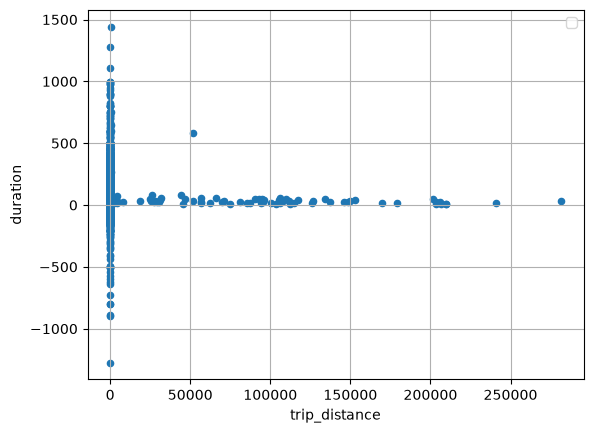

In [14]:
df.plot(kind = "scatter", x="trip_distance", y = "fare_amount")
plt.xlabel("trip_distance")
plt.ylabel("duration")
plt.grid(True)
plt.legend()
plt.show()

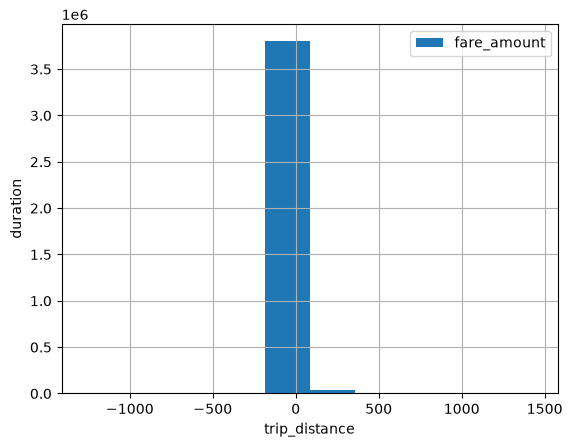

In [15]:
df.plot(kind = "hist", x="PULocationID", y = "fare_amount")
plt.xlabel("trip_distance")
plt.ylabel("duration")
plt.grid(True)
plt.legend()
plt.show()

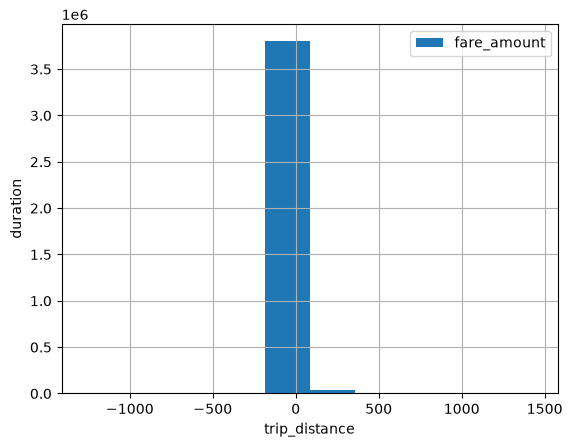

In [16]:
df.plot(kind = "hist", x="DOLocationID", y = "fare_amount")
plt.xlabel("trip_distance")
plt.ylabel("duration")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_407090/3590443446.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/home/abhinavmishra/Desktop/mlops-v3/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


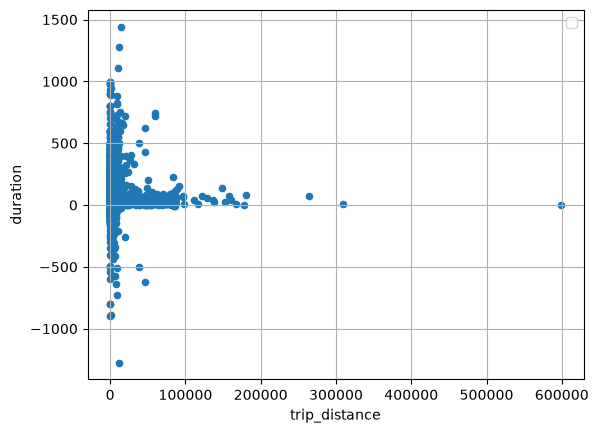

In [17]:
df.plot(kind = "scatter", x="duration", y = "fare_amount")
plt.xlabel("trip_distance")
plt.ylabel("duration")
plt.grid(True)
plt.legend()
plt.show()

In [20]:
corr = df.corr(numeric_only=True)
print(corr)

               trip_distance  PULocationID  DOLocationID  fare_amount  \
trip_distance       1.000000     -0.002319     -0.000986     0.009241   
PULocationID       -0.002319      1.000000      0.086648    -0.119749   
DOLocationID       -0.000986      0.086648      1.000000    -0.089997   
fare_amount         0.009241     -0.119749     -0.089997     1.000000   
duration            0.006028     -0.074886     -0.064111     0.412253   

               duration  
trip_distance  0.006028  
PULocationID  -0.074886  
DOLocationID  -0.064111  
fare_amount    0.412253  
duration       1.000000  


In [18]:
df.to_parquet(f'../datasets/processed/processed-{year}-{month}.parquet')